# Sentiment Analysis with Bidirectional LSTM on IMDB Dataset

This notebook implements a **Bidirectional LSTM (Bi-LSTM)** for binary sentiment classification (positive/negative) on the IMDB movie reviews dataset.

**Key concepts covered:**
- Why bidirectionality helps: forward context + backward context
- Bi-LSTM architecture: concatenating forward and backward hidden states
- Packed padded sequences for variable-length inputs
- Comparison: Unidirectional LSTM vs Bidirectional LSTM
- Attention-weighted pooling as an alternative to last-hidden-state pooling

**Bidirectional LSTM intuition:**  
A standard LSTM reads tokens left→right, so at position `t` it only has context from tokens `1..t`.  
A Bi-LSTM runs two LSTMs — one forward (left→right) and one backward (right→left) — then **concatenates** their hidden states at each step, giving every token access to the full sentence context.

In [1]:
import re
import time
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1) Load IMDB Dataset

In [2]:
from datasets import load_dataset

raw = load_dataset("imdb")
print(raw)
print("\nSample review:")
print(raw["train"][0]["text"][:300])
print("\nLabel:", raw["train"][0]["label"])  # 0=neg, 1=pos

/opt/miniconda3/envs/AI/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

Label: 0


## 2) Text Preprocessing & Vocabulary

In [3]:
def tokenize(text: str):
    """Simple whitespace + punctuation tokenizer."""
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)         # strip HTML tags
    text = re.sub(r"[^a-z0-9']", " ", text)       # keep letters/digits/apostrophe
    return text.split()

MAX_VOCAB = 20_000
MIN_FREQ  = 2
MAX_LEN   = 256      # truncate to keep sequences manageable

print("Building vocabulary...")
counter = Counter()
for ex in raw["train"]:
    counter.update(tokenize(ex["text"]))

SPECIAL = ["<pad>", "<unk>"]
vocab   = SPECIAL + [w for w, c in counter.most_common(MAX_VOCAB) if c >= MIN_FREQ]
stoi    = {w: i for i, w in enumerate(vocab)}

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

print(f"Vocabulary size: {len(vocab):,}")

Building vocabulary...
Vocabulary size: 20,002


## 3) Dataset & DataLoader

In [4]:
def encode(text: str, max_len: int = MAX_LEN):
    tokens = tokenize(text)[:max_len]
    return [stoi.get(t, UNK_IDX) for t in tokens]


class IMDBDataset(Dataset):
    def __init__(self, split):
        self.data = [
            (encode(ex["text"]), ex["label"])
            for ex in raw[split]
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids, label = self.data[idx]
        return (
            torch.tensor(ids,   dtype=torch.long),
            torch.tensor(label, dtype=torch.long),
        )


def collate_fn(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(t) for t in texts], dtype=torch.long)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    return texts_padded, torch.stack(labels), lengths


BATCH_SIZE = 64

train_ds = IMDBDataset("train")
test_ds  = IMDBDataset("test")

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(train_dl)} | Test batches: {len(test_dl)}")
x_s, y_s, l_s = next(iter(train_dl))
print("Batch shape:", x_s.shape, "| Labels:", y_s[:8], "| Lengths:", l_s[:8])

Train batches: 391 | Test batches: 391
Batch shape: torch.Size([64, 256]) | Labels: tensor([1, 0, 1, 1, 1, 0, 1, 0]) | Lengths: tensor([256, 256, 197, 130, 102, 139, 256, 131])


## 4) Bidirectional LSTM Architecture

```
Input tokens:  [w1,  w2,  w3,  ...,  wT]
                ↓    ↓    ↓          ↓
Embedding:     [e1,  e2,  e3,  ...,  eT]
                ↓    ↓    ↓          ↓
Forward LSTM:  h→1  h→2  h→3  ...  h→T   (left-to-right)
Backward LSTM: h←1  h←2  h←3  ...  h←T   (right-to-left)
                ↓                   ↓
Concat last:  [h→T || h←1]              → sentence vector (2H)
                ↓
Dropout + FC → logits (2 classes)
```

We implement **two pooling strategies** and compare them:
- **Last-hidden**: uses `h→T` (forward) and `h←1` (backward) — the final hidden states
- **Mean pooling**: averages all `[h→t || h←t]` across valid (non-padding) positions

In [5]:
class BiLSTMSentiment(nn.Module):
    """
    Bidirectional LSTM for sentiment classification.

    Parameters
    ----------
    vocab_size  : vocabulary size
    embed_dim   : embedding dimension
    hidden_size : LSTM hidden units per direction
    num_layers  : stacked LSTM layers
    dropout     : dropout probability
    num_classes : output classes (2 for binary)
    pad_idx     : padding token index
    pooling     : 'last' (final hidden states) or 'mean' (average all timesteps)
    """

    def __init__(
        self,
        vocab_size:  int,
        embed_dim:   int   = 128,
        hidden_size: int   = 128,
        num_layers:  int   = 2,
        dropout:     float = 0.5,
        num_classes: int   = 2,
        pad_idx:     int   = 0,
        pooling:     str   = "last",
    ):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        self.pooling     = pooling

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = True,       # <-- key flag
        )
        self.dropout = nn.Dropout(dropout)
        # *2 because we concatenate forward + backward hidden states
        self.fc      = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x, lengths):
        # x: (B, L)  lengths: (B,)
        embedded = self.dropout(self.embedding(x))          # (B, L, E)

        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        # output: packed  |  hidden: (num_layers*2, B, H)  |  cell: same
        packed_out, (hidden, cell) = self.lstm(packed)

        if self.pooling == "last":
            # hidden[-2]: last forward layer   hidden[-1]: last backward layer
            # Concat to form (B, 2H) sentence vector
            sentence = torch.cat([hidden[-2], hidden[-1]], dim=1)  # (B, 2H)

        else:  # mean pooling over valid (non-pad) timesteps
            output, _ = pad_packed_sequence(packed_out, batch_first=True)  # (B, L, 2H)
            # Mask padding positions before averaging
            mask = (x != 0).unsqueeze(-1).float()           # (B, L, 1)
            output = output * mask
            sentence = output.sum(dim=1) / lengths.unsqueeze(1).float().to(output.device)  # (B, 2H)

        return self.fc(self.dropout(sentence))               # (B, num_classes)


# Instantiate the Bi-LSTM model with last-hidden pooling
model = BiLSTMSentiment(
    vocab_size  = len(vocab),
    embed_dim   = 128,
    hidden_size = 128,
    num_layers  = 2,
    dropout     = 0.5,
    num_classes = 2,
    pad_idx     = PAD_IDX,
    pooling     = "last",
).to(device)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

BiLSTMSentiment(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

Trainable parameters: 3,220,226


## 5) Training & Evaluation Utilities

In [6]:
def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y, lengths in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x, lengths)
        loss   = loss_fn(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y, lengths in loader:
        x, y   = x.to(device), y.to(device)
        logits = model(x, lengths)
        loss   = loss_fn(logits, y)

        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)

    return total_loss / total, correct / total


def train_model(
    model, train_loader, test_loader,
    epochs=10, lr=1e-3, weight_decay=1e-4
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn   = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        te_loss, te_acc = evaluate(model, test_loader, loss_fn)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        print(
            f"Epoch {epoch:02d}/{epochs}  "
            f"train loss={tr_loss:.4f}  acc={tr_acc:.4f}  |  "
            f"test  loss={te_loss:.4f}  acc={te_acc:.4f}  "
            f"[{time.time()-t0:.1f}s]"
        )

    return history

## 6) Train the Bi-LSTM Model

In [7]:
history = train_model(
    model, train_dl, test_dl,
    epochs=10,
    lr=1e-3,
    weight_decay=1e-4,
)

print(f"\nBest test accuracy: {max(history['test_acc']):.4f}")

Epoch 01/10  train loss=0.6454  acc=0.6124  |  test  loss=0.5550  acc=0.7073  [16.2s]
Epoch 02/10  train loss=0.6069  acc=0.6647  |  test  loss=0.6875  acc=0.6908  [19.1s]
Epoch 03/10  train loss=0.5189  acc=0.7484  |  test  loss=0.4910  acc=0.7676  [18.3s]
Epoch 04/10  train loss=0.4434  acc=0.7991  |  test  loss=0.4587  acc=0.8008  [18.8s]
Epoch 05/10  train loss=0.4077  acc=0.8195  |  test  loss=0.4395  acc=0.8205  [18.4s]
Epoch 06/10  train loss=0.3701  acc=0.8392  |  test  loss=0.3808  acc=0.8418  [18.6s]
Epoch 07/10  train loss=0.3378  acc=0.8552  |  test  loss=0.3800  acc=0.8526  [18.9s]
Epoch 08/10  train loss=0.3216  acc=0.8648  |  test  loss=0.3708  acc=0.8503  [18.8s]
Epoch 09/10  train loss=0.3112  acc=0.8702  |  test  loss=0.3540  acc=0.8597  [18.6s]
Epoch 10/10  train loss=0.2972  acc=0.8771  |  test  loss=0.3858  acc=0.8614  [18.5s]

Best test accuracy: 0.8614


## 7) Plot Training Curves

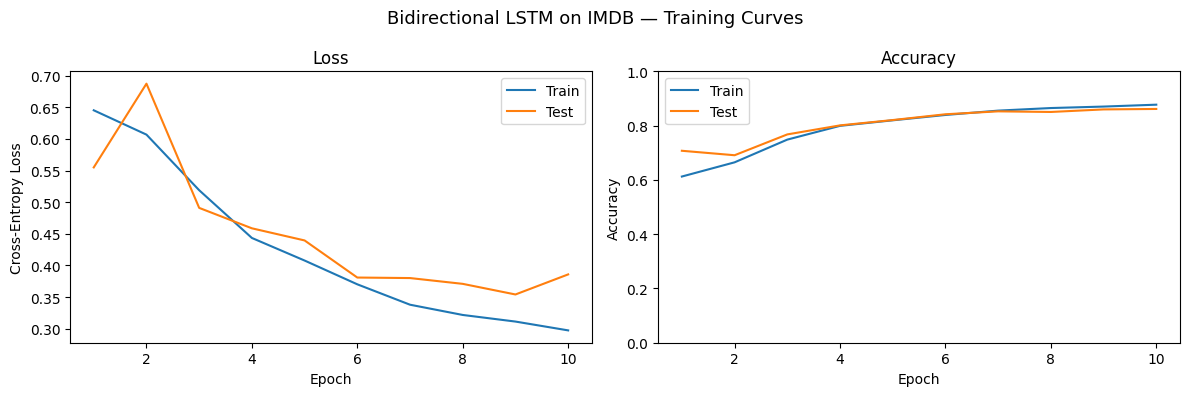

In [8]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["test_loss"],  label="Test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["test_acc"],  label="Test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()

fig.suptitle("Bidirectional LSTM on IMDB — Training Curves", fontsize=13)
plt.tight_layout()
plt.show()

## 8) Ablation: Unidirectional LSTM vs Bidirectional LSTM vs Pooling Strategies

We compare four configurations under identical hyperparameters:
1. **Uni-LSTM** — standard left-to-right LSTM, last hidden state
2. **Bi-LSTM (last)** — bidirectional, concat of last forward + backward hidden
3. **Bi-LSTM (mean)** — bidirectional, mean pooling over all timesteps
4. **Bi-LSTM (2-layer, mean)** — deeper bidirectional with mean pooling

In [9]:
# We reuse BiLSTMSentiment but expose bidirectional as a flag
class LSTMSentiment(nn.Module):
    """Unified LSTM classifier: unidirectional or bidirectional, last or mean pooling."""

    def __init__(
        self,
        vocab_size:    int,
        embed_dim:     int   = 128,
        hidden_size:   int   = 128,
        num_layers:    int   = 2,
        dropout:       float = 0.5,
        num_classes:   int   = 2,
        pad_idx:       int   = 0,
        bidirectional: bool  = True,
        pooling:       str   = "last",
    ):
        super().__init__()
        self.bidirectional = bidirectional
        self.pooling       = pooling
        self.num_dirs      = 2 if bidirectional else 1

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = bidirectional,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size * self.num_dirs, num_classes)

    def forward(self, x, lengths):
        embedded   = self.dropout(self.embedding(x))
        packed     = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, (hidden, _) = self.lstm(packed)

        if self.pooling == "last":
            if self.bidirectional:
                sentence = torch.cat([hidden[-2], hidden[-1]], dim=1)
            else:
                sentence = hidden[-1]
        else:  # mean
            output, _ = pad_packed_sequence(packed_out, batch_first=True)
            mask      = (x != 0).unsqueeze(-1).float()
            output    = output * mask
            sentence  = output.sum(dim=1) / lengths.unsqueeze(1).float().to(output.device)

        return self.fc(self.dropout(sentence))


ablation_configs = [
    {"bidirectional": False, "pooling": "last", "num_layers": 2, "label": "Uni-LSTM (last)"},
    {"bidirectional": True,  "pooling": "last", "num_layers": 2, "label": "Bi-LSTM (last)"},
    {"bidirectional": True,  "pooling": "mean", "num_layers": 2, "label": "Bi-LSTM (mean)"},
    {"bidirectional": True,  "pooling": "mean", "num_layers": 3, "label": "Bi-LSTM-3L (mean)"},
]

ABLATION_EPOCHS = 7
ablation_results = []

for cfg in ablation_configs:
    print(f"\n--- {cfg['label']} ---")
    m = LSTMSentiment(
        vocab_size    = len(vocab),
        embed_dim     = 128,
        hidden_size   = 128,
        num_layers    = cfg["num_layers"],
        dropout       = 0.5,
        num_classes   = 2,
        pad_idx       = PAD_IDX,
        bidirectional = cfg["bidirectional"],
        pooling       = cfg["pooling"],
    ).to(device)
    h = train_model(m, train_dl, test_dl, epochs=ABLATION_EPOCHS, lr=1e-3)
    best_acc = max(h["test_acc"])
    ablation_results.append({"label": cfg["label"], "best_test_acc": best_acc, "history": h})
    print(f"Best test acc: {best_acc:.4f}")


--- Uni-LSTM (last) ---
Epoch 01/7  train loss=0.6711  acc=0.5718  |  test  loss=0.5958  acc=0.6816  [11.4s]
Epoch 02/7  train loss=0.6098  acc=0.6779  |  test  loss=0.6094  acc=0.6946  [11.1s]
Epoch 03/7  train loss=0.5314  acc=0.7458  |  test  loss=0.4699  acc=0.7956  [11.0s]
Epoch 04/7  train loss=0.4497  acc=0.8008  |  test  loss=0.4763  acc=0.7952  [10.9s]
Epoch 05/7  train loss=0.4037  acc=0.8269  |  test  loss=0.5337  acc=0.7571  [9.0s]
Epoch 06/7  train loss=0.3750  acc=0.8382  |  test  loss=0.4290  acc=0.8174  [9.1s]
Epoch 07/7  train loss=0.3353  acc=0.8592  |  test  loss=0.4301  acc=0.8269  [7.2s]
Best test acc: 0.8269

--- Bi-LSTM (last) ---
Epoch 01/7  train loss=0.6539  acc=0.6044  |  test  loss=0.5724  acc=0.7043  [13.0s]
Epoch 02/7  train loss=0.5913  acc=0.6861  |  test  loss=0.6305  acc=0.6895  [12.6s]
Epoch 03/7  train loss=0.5286  acc=0.7410  |  test  loss=0.5992  acc=0.6898  [11.9s]
Epoch 04/7  train loss=0.4591  acc=0.7913  |  test  loss=0.4374  acc=0.8056  [12.3

Config                  Best Test Acc
--------------------------------------
Uni-LSTM (last)                0.8269
Bi-LSTM (last)                 0.8468
Bi-LSTM (mean)                 0.8689
Bi-LSTM-3L (mean)              0.8673


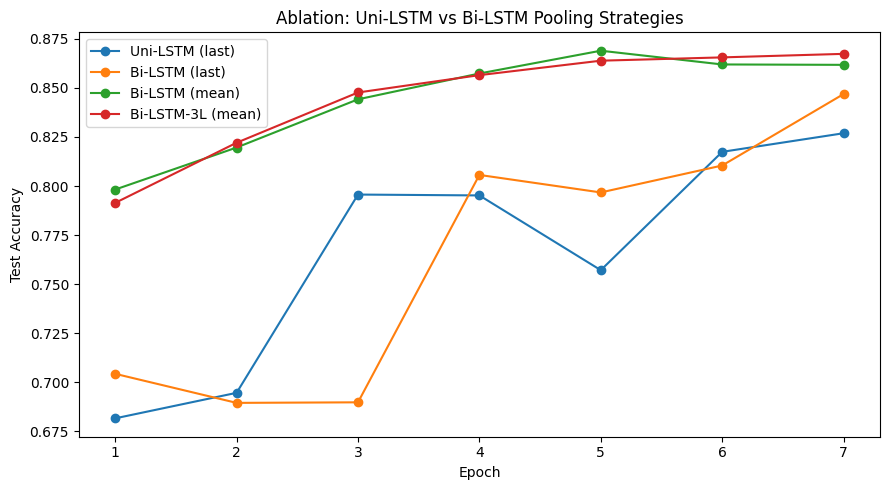

In [10]:
# Summary table
print(f"{'Config':<22} {'Best Test Acc':>14}")
print("-" * 38)
for r in ablation_results:
    print(f"{r['label']:<22} {r['best_test_acc']:>14.4f}")

# Plot test accuracy curves
plt.figure(figsize=(9, 5))
for r in ablation_results:
    plt.plot(range(1, ABLATION_EPOCHS + 1), r["history"]["test_acc"], marker="o", label=r["label"])
plt.title("Ablation: Uni-LSTM vs Bi-LSTM Pooling Strategies")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 9) Per-class Metrics (Precision, Recall, F1)

Accuracy alone can be misleading on balanced datasets. We compute per-class metrics to verify the model isn't biased toward one sentiment.

In [11]:
@torch.no_grad()
def get_predictions(m, loader):
    m.eval()
    all_preds, all_labels = [], []
    for x, y, lengths in loader:
        x = x.to(device)
        logits = m(x, lengths)
        preds  = logits.argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y)
    return torch.cat(all_preds), torch.cat(all_labels)


preds, labels = get_predictions(model, test_dl)

# Compute per-class precision, recall, F1
for cls, name in enumerate(["Negative", "Positive"]):
    tp = ((preds == cls) & (labels == cls)).sum().item()
    fp = ((preds == cls) & (labels != cls)).sum().item()
    fn = ((preds != cls) & (labels == cls)).sum().item()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    print(f"{name:10s}  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}")

overall_acc = (preds == labels).float().mean().item()
print(f"\nOverall Accuracy: {overall_acc:.4f}")

Negative    Precision=0.8805  Recall=0.8362  F1=0.8578
Positive    Precision=0.8441  Recall=0.8865  F1=0.8648

Overall Accuracy: 0.8614


## 10) Confusion Matrix

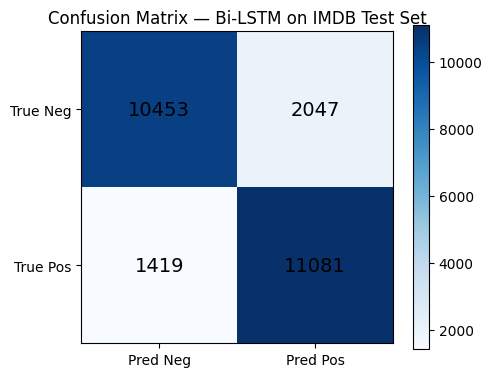

In [12]:
num_classes = 2
conf_matrix = torch.zeros(num_classes, num_classes, dtype=torch.long)
for p, l in zip(preds, labels):
    conf_matrix[l, p] += 1

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(conf_matrix.numpy(), cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred Neg", "Pred Pos"])
ax.set_yticklabels(["True Neg", "True Pos"])
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, conf_matrix[i, j].item(), ha="center", va="center", fontsize=14)
ax.set_title("Confusion Matrix — Bi-LSTM on IMDB Test Set")
plt.colorbar(im)
plt.tight_layout()
plt.show()

## 11) Inference on Custom Reviews

In [13]:
@torch.no_grad()
def predict(text: str, m=model):
    m.eval()
    ids = encode(text)
    if not ids:
        return "unknown", 0.0
    x       = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)  # (1, L)
    lengths = torch.tensor([len(ids)], dtype=torch.long)
    logits  = m(x, lengths)
    probs   = F.softmax(logits, dim=1)[0]
    label   = int(logits.argmax(1).item())
    return ("positive" if label == 1 else "negative"), float(probs[label])


test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat.",
    "Terrible film. Boring, predictable, and a complete waste of time. I walked out after 30 minutes.",
    "It was okay, nothing special. Some scenes were good but overall it felt a bit flat.",
    "One of the best movies I've seen in years. A masterpiece of storytelling and cinematography.",
    "The movie started slow but the ending completely redeemed it — absolutely worth watching.",
    "Despite the great cast, the script was dull and the pacing was painfully slow throughout.",
]

print(f"{'Review':<70} {'Sentiment':<12} {'Confidence'}")
print("-" * 97)
for review in test_reviews:
    sentiment, confidence = predict(review)
    print(f"{review[:68]:<70} {sentiment:<12} {confidence:.4f}")

Review                                                                 Sentiment    Confidence
-------------------------------------------------------------------------------------------------
This movie was absolutely fantastic! The acting was superb and the p   positive     0.9122
Terrible film. Boring, predictable, and a complete waste of time. I    negative     0.9937
It was okay, nothing special. Some scenes were good but overall it f   negative     0.8996
One of the best movies I've seen in years. A masterpiece of storytel   positive     0.9958
The movie started slow but the ending completely redeemed it — absol   negative     0.6507
Despite the great cast, the script was dull and the pacing was painf   negative     0.8877


## Summary

| Component | Detail |
|---|---|
| Dataset | IMDB (25k train / 25k test) |
| Vocabulary | Top 20,000 words, min freq=2 |
| Max sequence length | 256 tokens |
| Embedding | 128-dim trainable |
| Architecture | Bidirectional LSTM (2 layers × 128 hidden/dir) |
| FC input | 256-dim (128 forward + 128 backward) |
| Sequence handling | Packed padded sequences |
| Dropout | 0.5 between layers and before FC |
| Gradient clipping | max_norm=1.0 |
| Optimizer | Adam (lr=1e-3, weight_decay=1e-4) |
| LR schedule | StepLR (step=3, gamma=0.5) |

**Why Bidirectional LSTM outperforms Unidirectional LSTM:**  
Sentiment cues can appear anywhere in a review — negations before a positive phrase ("not good"), or qualifiers after ("great, but..."). A Uni-LSTM only encodes context *up to* the current word; at the final hidden state it has seen all tokens but the representation is dominated by recent words. A Bi-LSTM reads the sequence in both directions and at each position has access to the full surrounding context, producing richer token representations and a more informative sentence vector.

**Pooling strategy:**  
`last` pooling uses only the final hidden states (one forward, one backward). `mean` pooling averages all timestep outputs, incorporating information from every position equally — often marginally better when sentiment is distributed across the full review rather than concentrated at the end.